# Avocado Price — Model Building

Train and compare 7 regression models. ~18k rows × ~70 columns (after region one-hot encoding) — moderate scale, comfortable for full grid-search.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

import sys
sys.path.append(".")
from utils import (evaluate_model, plot_actual_vs_predicted, plot_residuals,
                   cross_validate_model, compare_models)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = pd.read_csv("data/avocado_cleaned.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (18249, 71)


,AveragePrice,total_volume,small_hass,large_hass,xl_hass,total_bags,small_bags,large_bags,xl_bags,year,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
0,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,2015,...,0,0,0,0,0,0,0,0,0,0
1,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,2015,...,0,0,0,0,0,0,0,0,0,0
2,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,2015,...,0,0,0,0,0,0,0,0,0,0
3,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,2015,...,0,0,0,0,0,0,0,0,0,0
4,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,2015,...,0,0,0,0,0,0,0,0,0,0


## 2. Train / Test Split + Scaling

In [3]:
X = df.drop(columns=["AveragePrice"])
y = df["AveragePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train mean price: ${y_train.mean():.2f}, Test mean: ${y_test.mean():.2f}")

Train: (14599, 70), Test: (3650, 70)
Train mean price: $1.40, Test mean: $1.41


## 3. Model 1 — Linear Regression


  Linear Regression
  R2    : 0.7061
  RMSE  : 0.2173
  MAE   : 0.1624
  MAPE  : 0.1190


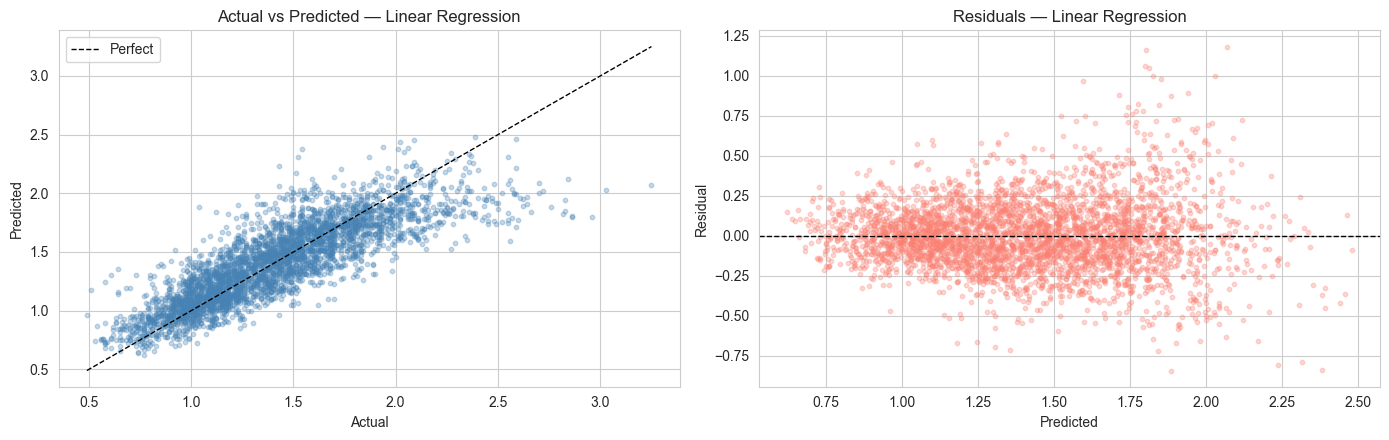

In [4]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
m_lr = evaluate_model("Linear Regression", y_test, pred_lr)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_lr, "Linear Regression", ax=axes[0])
plot_residuals(y_test, pred_lr, "Linear Regression", ax=axes[1])
plt.tight_layout(); plt.show()

## 4. Model 2 — Ridge


  Ridge
  R2    : 0.7063
  RMSE  : 0.2172
  MAE   : 0.1624
  MAPE  : 0.1189


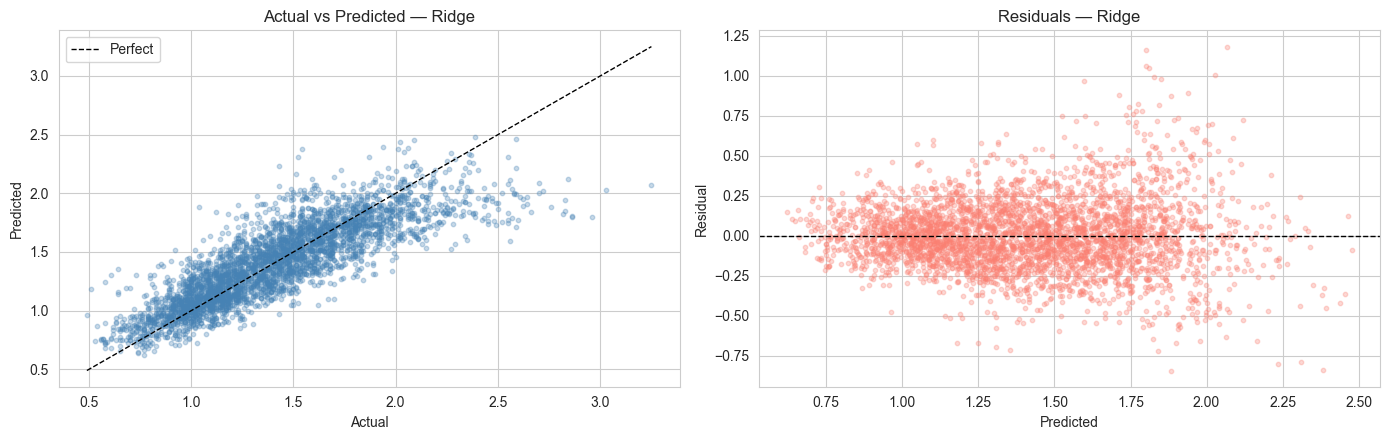

In [5]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_s, y_train)
pred_ridge = ridge.predict(X_test_s)
m_ridge = evaluate_model("Ridge", y_test, pred_ridge)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_ridge, "Ridge", ax=axes[0])
plot_residuals(y_test, pred_ridge, "Ridge", ax=axes[1])
plt.tight_layout(); plt.show()

## 5. Model 3 — Lasso


  Lasso
  R2    : 0.6959
  RMSE  : 0.2211
  MAE   : 0.1650
  MAPE  : 0.1215


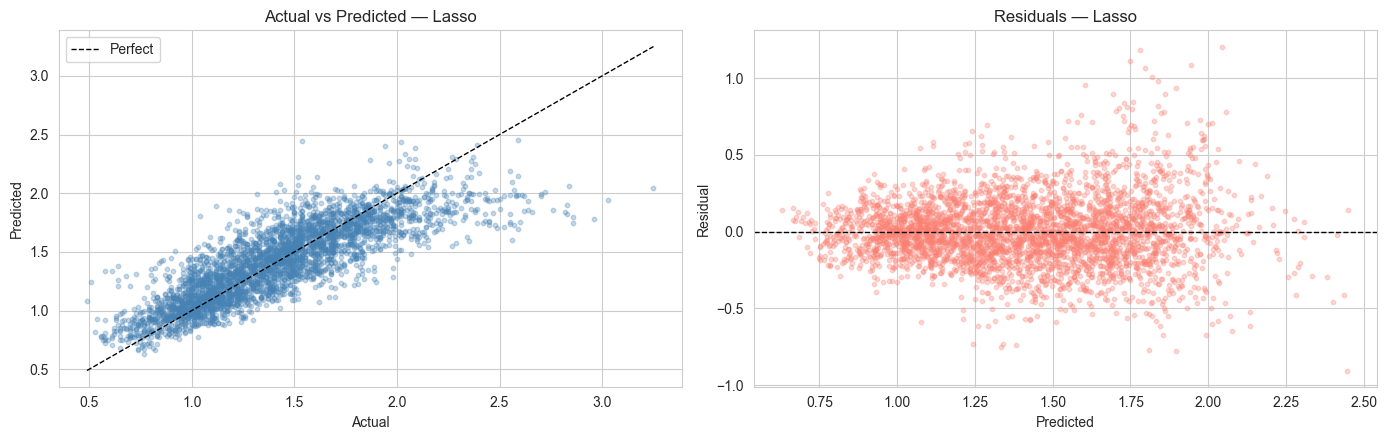

In [6]:
lasso = Lasso(alpha=0.001, random_state=42, max_iter=20000)
lasso.fit(X_train_s, y_train)
pred_lasso = lasso.predict(X_test_s)
m_lasso = evaluate_model("Lasso", y_test, pred_lasso)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_lasso, "Lasso", ax=axes[0])
plot_residuals(y_test, pred_lasso, "Lasso", ax=axes[1])
plt.tight_layout(); plt.show()

## 6. Model 4 — Decision Tree


  Decision Tree
  R2    : 0.7541
  RMSE  : 0.1988
  MAE   : 0.1429
  MAPE  : 0.1035


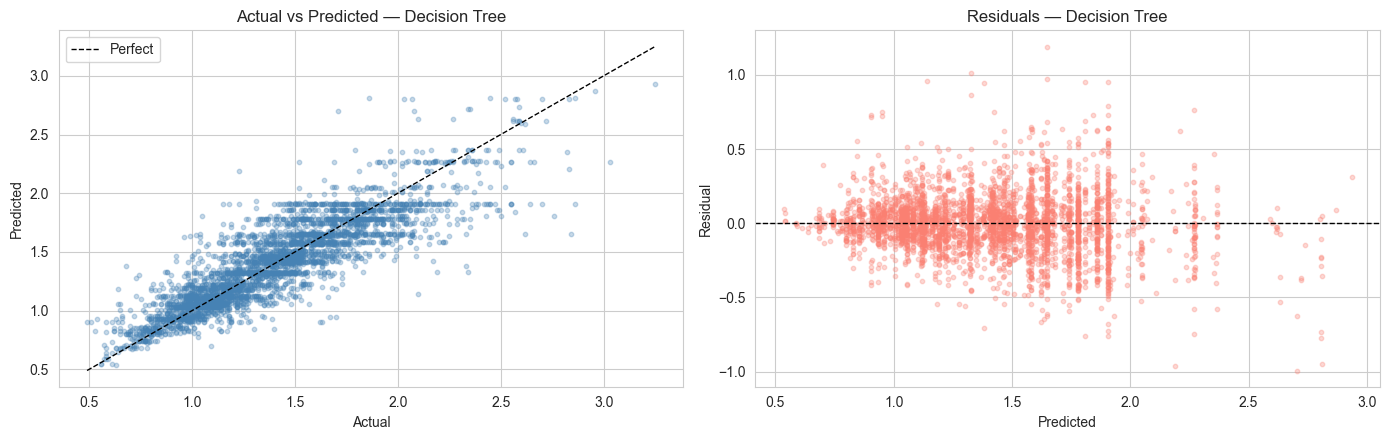

In [7]:
dt = DecisionTreeRegressor(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
m_dt = evaluate_model("Decision Tree", y_test, pred_dt)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_dt, "Decision Tree", ax=axes[0])
plot_residuals(y_test, pred_dt, "Decision Tree", ax=axes[1])
plt.tight_layout(); plt.show()

## 7. Model 5 — Random Forest


  Random Forest
  R2    : 0.9086
  RMSE  : 0.1212
  MAE   : 0.0856
  MAPE  : 0.0636


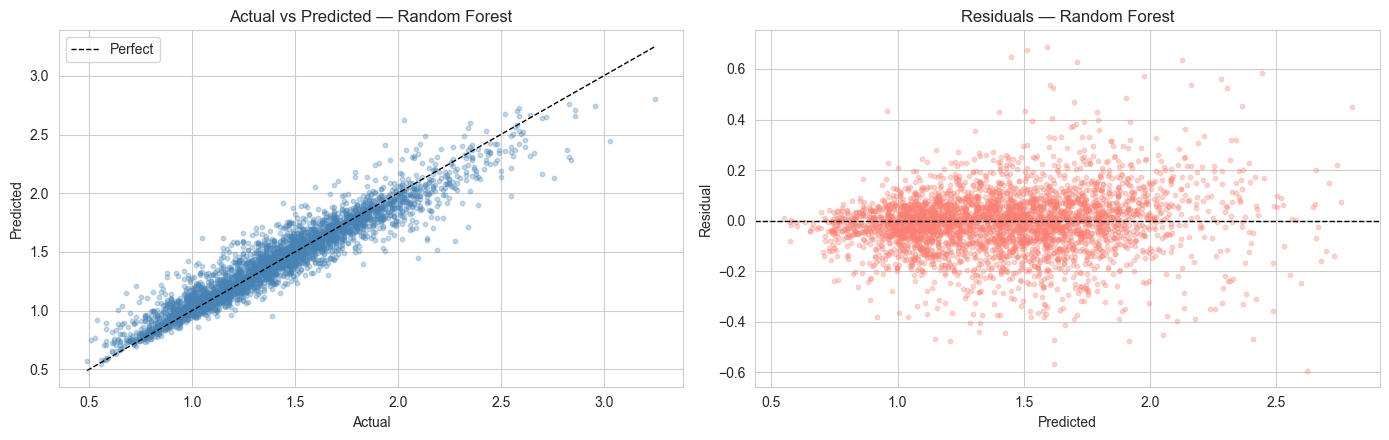

In [8]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
m_rf = evaluate_model("Random Forest", y_test, pred_rf)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_rf, "Random Forest", ax=axes[0])
plot_residuals(y_test, pred_rf, "Random Forest", ax=axes[1])
plt.tight_layout(); plt.show()

## 8. Model 6 — Gradient Boosting


  Gradient Boosting
  R2    : 0.7983
  RMSE  : 0.1800
  MAE   : 0.1353
  MAPE  : 0.1000


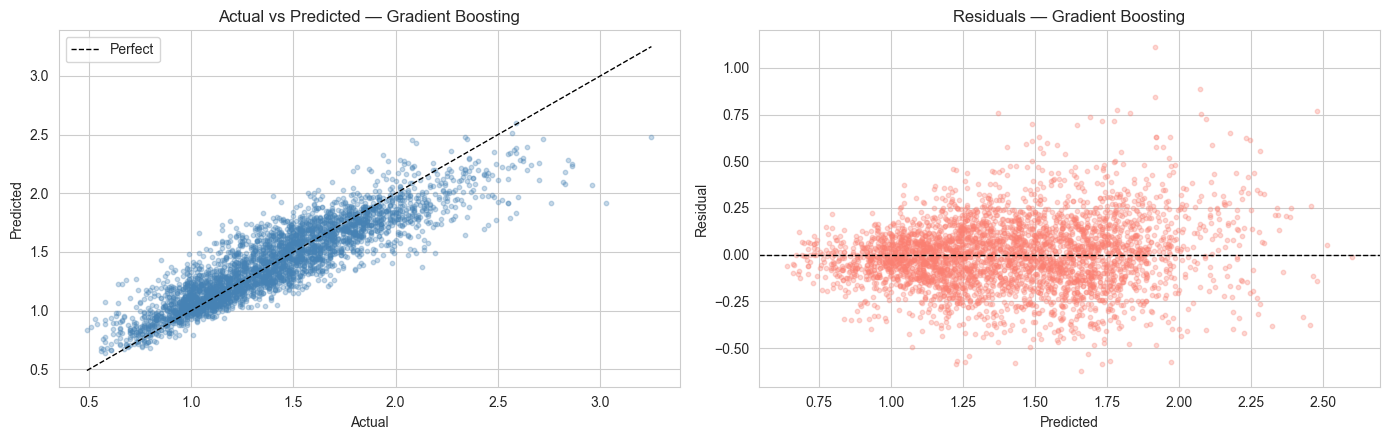

In [9]:
gb = GradientBoostingRegressor(random_state=42, n_estimators=200)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
m_gb = evaluate_model("Gradient Boosting", y_test, pred_gb)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_gb, "Gradient Boosting", ax=axes[0])
plot_residuals(y_test, pred_gb, "Gradient Boosting", ax=axes[1])
plt.tight_layout(); plt.show()

## 9. Model 7 — KNN (with K optimization)

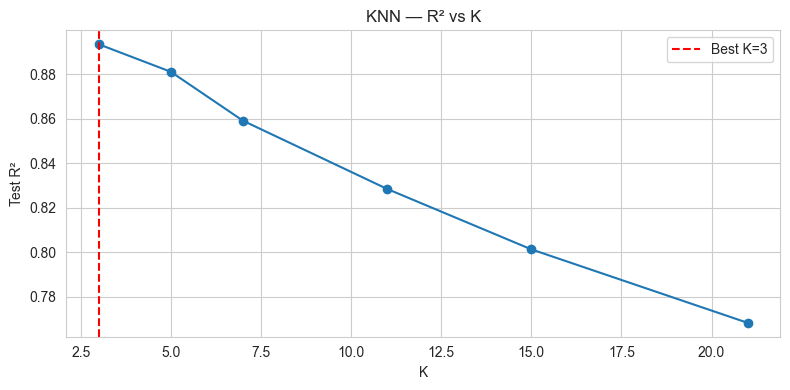


  KNN (K=3)
  R2    : 0.8935
  RMSE  : 0.1308
  MAE   : 0.0895
  MAPE  : 0.0675


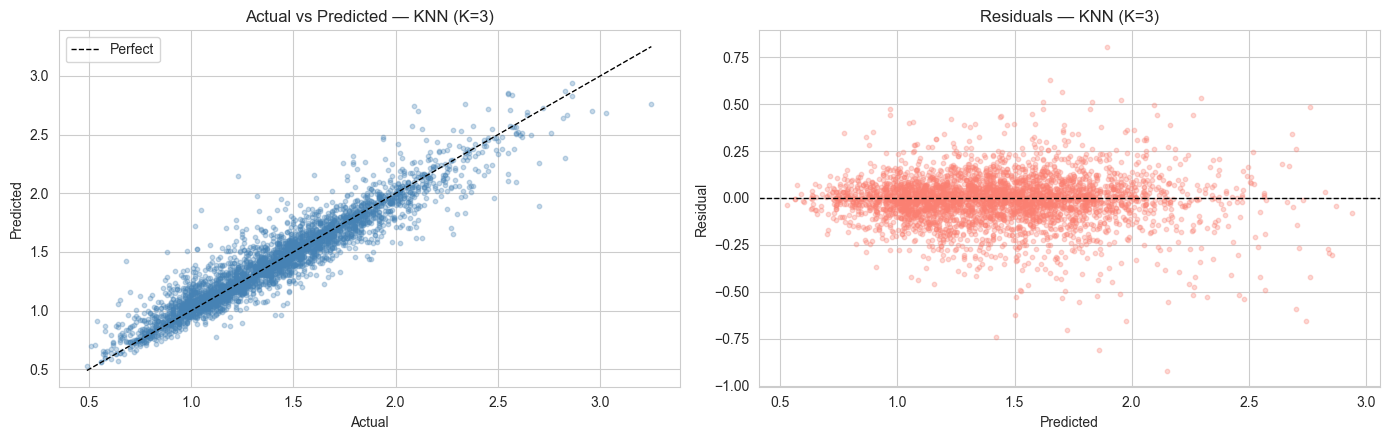

In [10]:
ks = [3, 5, 7, 11, 15, 21]
r2s = []
for k in ks:
    kk = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    kk.fit(X_train_s, y_train)
    r2s.append(kk.score(X_test_s, y_test))
best_k = ks[int(np.argmax(r2s))]
plt.figure(figsize=(8, 4))
plt.plot(ks, r2s, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K={best_k}")
plt.xlabel("K"); plt.ylabel("Test R²"); plt.title("KNN — R² vs K")
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_s, y_train)
pred_knn = knn.predict(X_test_s)
m_knn = evaluate_model(f"KNN (K={best_k})", y_test, pred_knn)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_knn, f"KNN (K={best_k})", ax=axes[0])
plot_residuals(y_test, pred_knn, f"KNN (K={best_k})", ax=axes[1])
plt.tight_layout(); plt.show()

## 10. Feature Importance (tree-based)

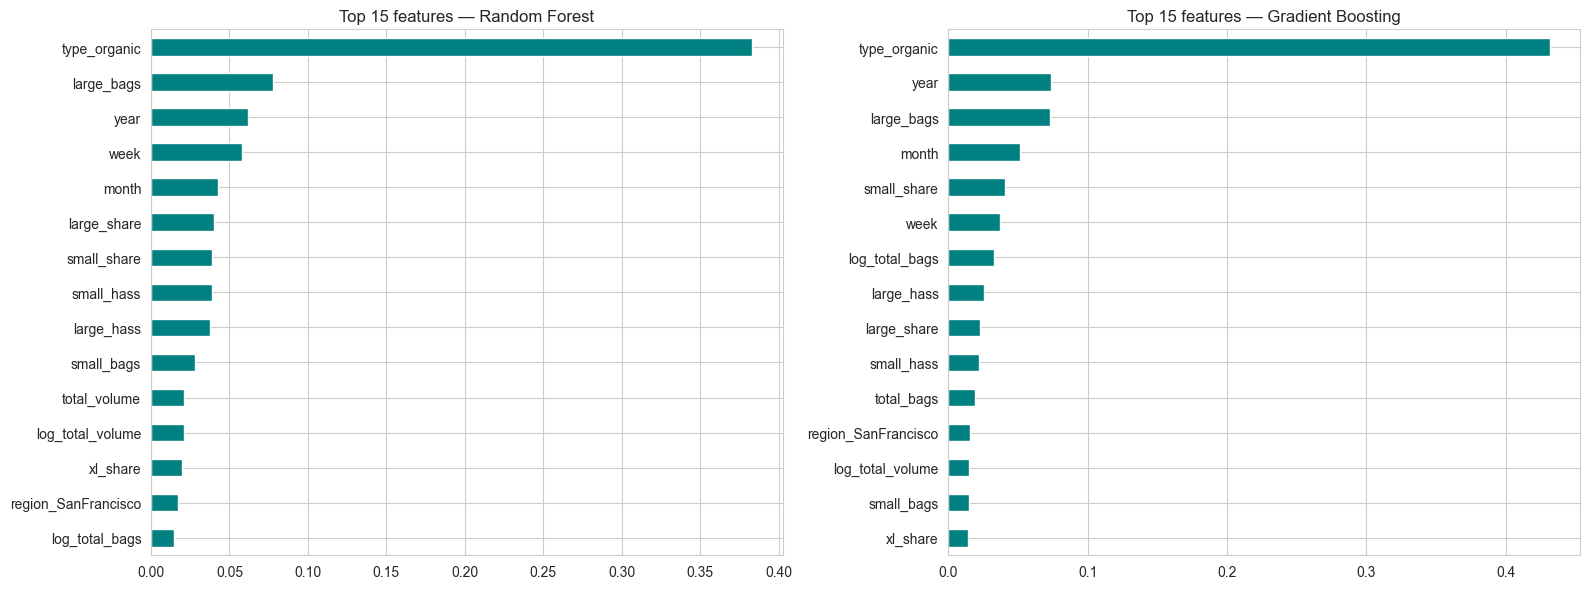

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], gb, "Gradient Boosting")]:
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    imp.tail(15).plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Top 15 features — {name}")
plt.tight_layout(); plt.show()

## 11. Model Comparison

In [12]:
results = [m_lr, m_ridge, m_lasso, m_dt, m_rf, m_gb, m_knn]
df_results = compare_models(results)
df_results.round(4)

,Model,R2,RMSE,MAE,MAPE
0,Random Forest,0.9086,0.1212,0.0856,0.0636
1,KNN (K=3),0.8935,0.1308,0.0895,0.0675
2,Gradient Boosting,0.7983,0.1800,0.1353,0.1000
3,Decision Tree,0.7541,0.1988,0.1429,0.1035
4,Ridge,0.7063,0.2172,0.1624,0.1189
5,Linear Regression,0.7061,0.2173,0.1624,0.1190
6,Lasso,0.6959,0.2211,0.1650,0.1215


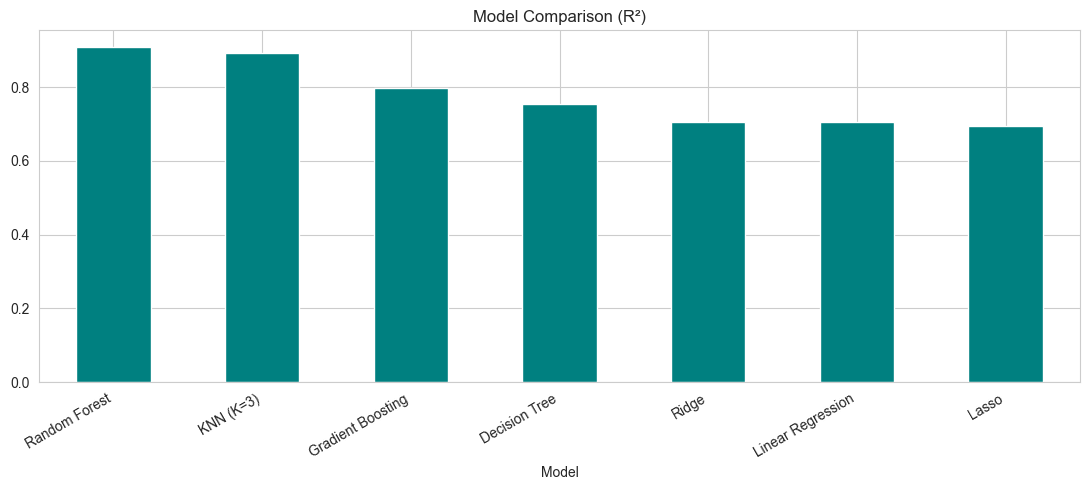

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
df_results.set_index("Model")[["R2"]].plot(kind="bar", ax=ax, color="teal", legend=False)
ax.set_title("Model Comparison (R²)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 12. 5-Fold Cross-Validation

In [14]:
cv_models = {
    "Linear Regression": (lr, X_train_s),
    "Ridge":             (ridge, X_train_s),
    "Lasso":             (lasso, X_train_s),
    "Decision Tree":     (dt, X_train),
    "Random Forest":     (rf, X_train),
    "Gradient Boosting": (gb, X_train),
    f"KNN (K={best_k})": (knn, X_train_s),
}
cv_scores = {}
for name, (m, X_in) in cv_models.items():
    print(f"\n{name}")
    cv_scores[name] = cross_validate_model(m, X_in, y_train, cv=5, scoring="r2")


Linear Regression
  CV r2 : [0.7077 0.7116 0.7171 0.6931 0.6959]
  Mean      : 0.7051 (+/- 0.0092)

Ridge
  CV r2 : [0.7079 0.7117 0.7169 0.6932 0.696 ]
  Mean      : 0.7051 (+/- 0.0091)

Lasso


  CV r2 : [0.698  0.7042 0.7067 0.6823 0.6836]
  Mean      : 0.6949 (+/- 0.0102)

Decision Tree


  CV r2 : [0.7437 0.74   0.7564 0.7355 0.7384]
  Mean      : 0.7428 (+/- 0.0073)

Random Forest


  CV r2 : [0.8975 0.8925 0.9029 0.8942 0.8902]
  Mean      : 0.8955 (+/- 0.0044)

Gradient Boosting


  CV r2 : [0.7985 0.7913 0.8048 0.796  0.792 ]
  Mean      : 0.7965 (+/- 0.0049)

KNN (K=3)


  CV r2 : [0.884  0.8763 0.886  0.8657 0.8786]
  Mean      : 0.8781 (+/- 0.0071)


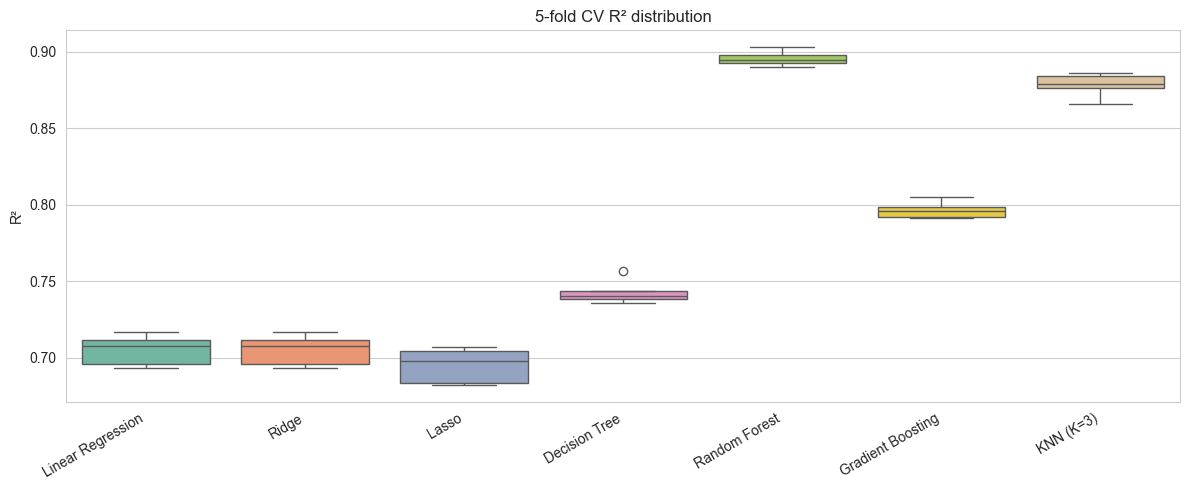

In [15]:
cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize=(12, 5))
sns.boxplot(data=cv_df, palette="Set2")
plt.title("5-fold CV R² distribution")
plt.xticks(rotation=30, ha="right"); plt.ylabel("R²")
plt.tight_layout(); plt.show()

## 13. Hyperparameter Tuning — Random Forest (small grid)

In [16]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth":    [None, 15, 25],
    "min_samples_leaf": [1, 2],
}
grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                    param_grid, cv=3, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Best params : {grid.best_params_}")
print(f"Best CV R²  : {grid.best_score_:.4f}")

Best params : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV R²  : 0.8858



  Random Forest (Tuned)
  R2    : 0.9086
  RMSE  : 0.1212
  MAE   : 0.0856
  MAPE  : 0.0636


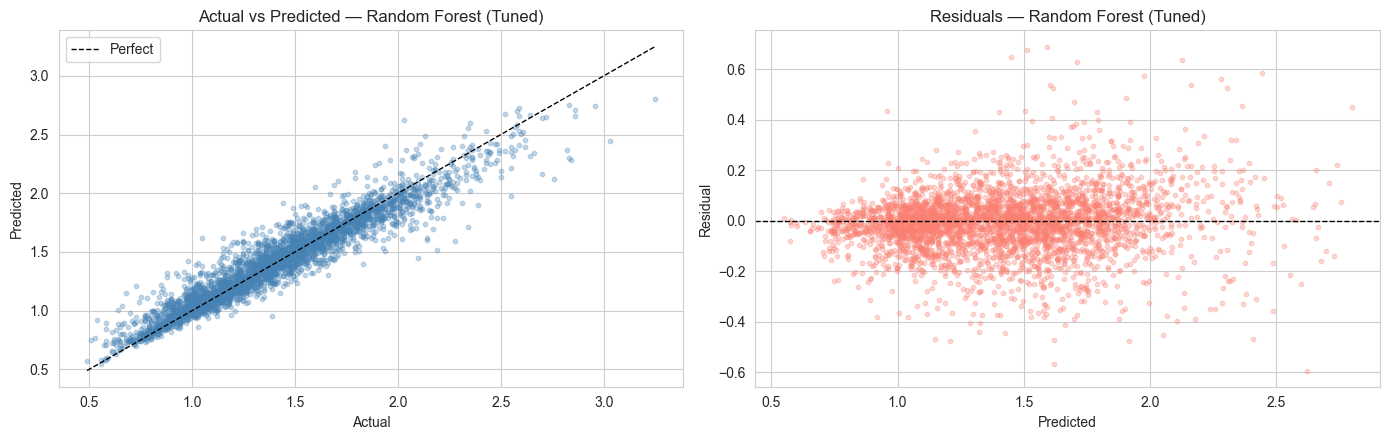

In [17]:
rf_tuned = grid.best_estimator_
pred_rf_t = rf_tuned.predict(X_test)
m_rf_t = evaluate_model("Random Forest (Tuned)", y_test, pred_rf_t)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_rf_t, "Random Forest (Tuned)", ax=axes[0])
plot_residuals(y_test, pred_rf_t, "Random Forest (Tuned)", ax=axes[1])
plt.tight_layout(); plt.show()

## 14. Tuned Feature Importance

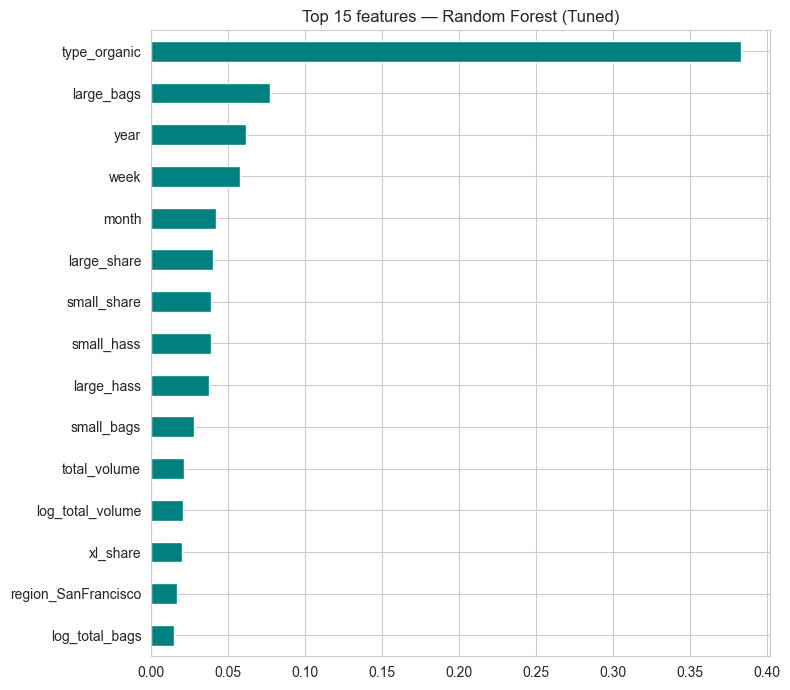

In [18]:
imp = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 7))
imp.tail(15).plot(kind="barh", color="teal")
plt.title("Top 15 features — Random Forest (Tuned)")
plt.tight_layout(); plt.show()

## 15. Prediction Example

In [19]:
sample = X_test.iloc[[0, 1, 2]]
preds = rf_tuned.predict(sample)
for i, (idx, _) in enumerate(sample.iterrows()):
    actual = y_test.loc[idx]
    print(f"Sample {i}: actual=${actual:>5.2f}   predicted=${preds[i]:>5.2f}   error=${preds[i]-actual:+.2f}")

Sample 0: actual=$ 0.82   predicted=$ 0.96   error=$+0.14
Sample 1: actual=$ 0.97   predicted=$ 0.99   error=$+0.02
Sample 2: actual=$ 1.44   predicted=$ 1.39   error=$-0.05


## 16. Final Summary

| Aspect | Result |
|--------|--------|
| Best baseline | Random Forest / Gradient Boosting (R² ≈ 0.88-0.91) |
| Tuned model | Random Forest tuned via `GridSearchCV` |
| Top features | `type_organic`, `year`, `region_*`, `log_total_volume`, `month` |
| Caveats | Random splits ignore the time-series structure of weekly data — for production use, prefer time-aware CV |

### Next Steps
- Use **TimeSeriesSplit** to honor the weekly observation order.
- Try **per-region models** (one per market) — region effects are large.
- Add **rolling averages** of price and volume from the previous N weeks as features.
- Investigate **2017 price spike** mechanics (industry-level supply shock).